# Swin, an adaptive attacker and the cost of the defense

3 questions the ViT-B/16 results do not answer on their own. Does the ranking transfer to an architecture whose attention is windowed rather than global and which has no class token? What happens when the attacker knows PSBD exists and trains against it, and does a union of probes restore detection? And what does the defense cost in forward passes against a plain prediction, and what does a larger $k$ buy? All 3 read cached results only. The Swin section reads `results/swin_*/psbd_metrics.json` through `scripts/paper/tab_swin.py`, the attacker section reads `results/adaptive_attacker_analysis.json` and `results/multi_probe_analysis.json` through `scripts/paper/tab_adaptive.py`, the union section reads `results/_experiments/probe_union/probe_union.json`. The cost section reads `results/_experiments/psbd_cost/cost.json` and the $k$ macros of `scripts/paper/fig_forward_passes.py`. Every number the text states is asserted against the macro sidecar the paper prints. The notebook runs on CPU in about 1 minute.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

from defenses.decision import PUBLISHED_PLACEMENT, RECOMMENDED_PLACEMENT
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    HEADLINE_KEY,
    attack_label,
    bootstrap_ci,
    dataset_label,
    fmt,
    load_coverage,
    load_declaration,
    load_json,
    mean_or_none,
    ordinal,
    placement_words,
)
from scripts.paper._common import clearing_cells as clearing_cells_of
from scripts.paper._style import attack_color, legend_above

declaration = load_declaration("configs/psbd_basis.json")

## The Swin-S architecture

Swin-S (torchvision `swin_s`) cuts the image into $4\times4$ patches, $56\times56$ tokens at the first of 4 stages, and restricts self-attention to $7\times7$ windows that alternate with windows shifted by 3, so a token reaches the rest of the image only through the shifted windows and through **patch merging** between stages. It has 24 blocks in stages of 2, 2, 18 and 2 and **no class token**: the head reads the average of the last stage's 49 tokens. `models.positions.SWIN_POSITIONS` gives the same position names as ViT on each block's `norm1`, `attn`, `norm2` and `mlp`, so PSBD-TM and PSBD-RD are defined on Swin by the same ids. If PSBD-TM works because the class token reads a patch trigger late through global attention, as `mechanism.ipynb` measured on ViT, then windowing and pooling are a real test of it.

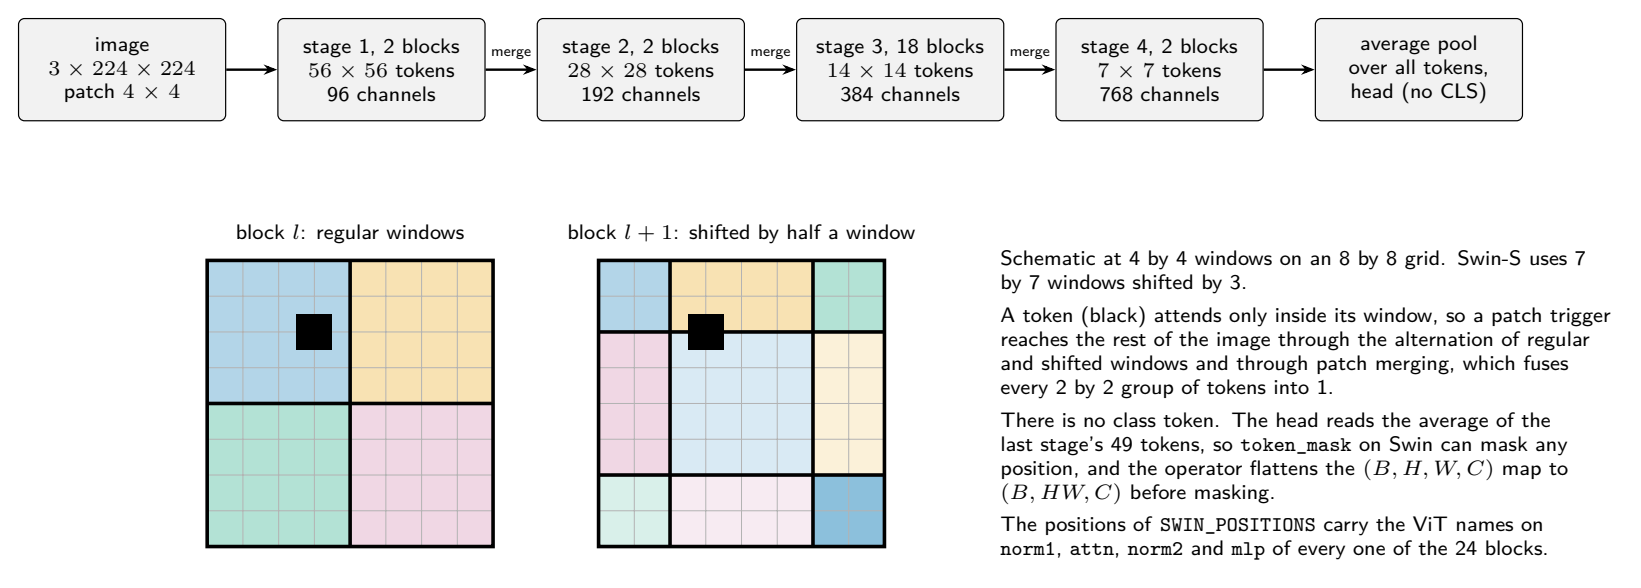

In [2]:
show_diagram("swin_windows")

## The Swin models

Swin follows exactly the ViT panel rule. `scripts.paper._common.swin_coverage` retargets the declaration of `configs/psbd_basis.json` to Swin-S (the same datasets, poison rates, canonical variants and excluded folder tokens, with the benign Swin-S model as each dataset's reference) and builds the coverage ledger in memory with the ledger's own verdicts, and `tab_swin.swin_cells` keeps the successful backdoors (`successful_2pt`) that carry a PSBD cache. So a 0.5% model, a Label-Consistent model without its adversarial bases, or a diverged, source-mapped or clean-accuracy-failing Swin model is not read. Swin was trained on the same panel datasets with the same recipe as ViT.

In [3]:
from scripts.paper import tab_swin

swin = tab_swin.swin_cells("results", "checkpoints", declaration["asr_bar"])
assert str(len(swin)) == macro("swin", "SwinCells")
swin_frame = pd.DataFrame([{k: c[k] for k in ("folder", "dataset", "attack", "poison_rate", "asr")} for c in swin])
print(f"{len(swin)} successful Swin-S models, above the {declaration['asr_bar']} bar and within the clean-accuracy bar")
vit_clearing_count = len(clearing_cells_of(load_coverage("results")))
swin_only_more = [attack_label(a) for a in sorted(swin_frame["attack"].unique()) if (swin_frame["attack"] == a).sum() > sum(c["attack"] == a for c in clearing_cells_of(load_coverage("results")))]
swin_frame.assign(dataset=swin_frame["dataset"].map(dataset_label), attack=swin_frame["attack"].map(attack_label)).groupby(["attack", "dataset"]).size().unstack(fill_value=0)

65 successful Swin-S models, above the 0.85 bar and within the clean-accuracy bar


dataset,CIFAR-10,CIFAR-100,GTSRB,Tiny ImageNet
attack,,,,
Adaptive-Blend,2,2,2,1
BPP,3,3,3,3
BadNets,3,3,3,3
Blend,3,3,3,3
LF,3,3,3,3
TaCT,2,0,0,0
WaNet,2,2,2,2


In [4]:
display(Markdown(rf"""
{len(swin)} Swin models are successful backdoors (`\SwinCells`) against {vit_clearing_count} ViT models, and {word_list(swin_only_more)} implant on more Swin models than ViT models. The composition differs from the ViT panel, so a mean over Swin and a mean over ViT answer slightly different questions, which the paired scatter further down avoids.
"""))


65 Swin models are successful backdoors (`\SwinCells`) against 62 ViT models, and Adaptive-Blend and WaNet implant on more Swin models than ViT models. The composition differs from the ViT panel, so a mean over Swin and a mean over ViT answer slightly different questions, which the paired scatter further down avoids.


## Placements on Swin

The paper reports 5 placements on Swin: PSBD-TM, its twin (token masking on the attention branch output before the add), dropout at the attention input, dropout before both adds and PSBD-RD. The left panel gives each mean AUROC at the adaptive rule over the models it reaches, the right panel the paired gains the paper prints, each with a 95% bootstrap interval over models, recomputed with `tab_swin.paired_gain`.

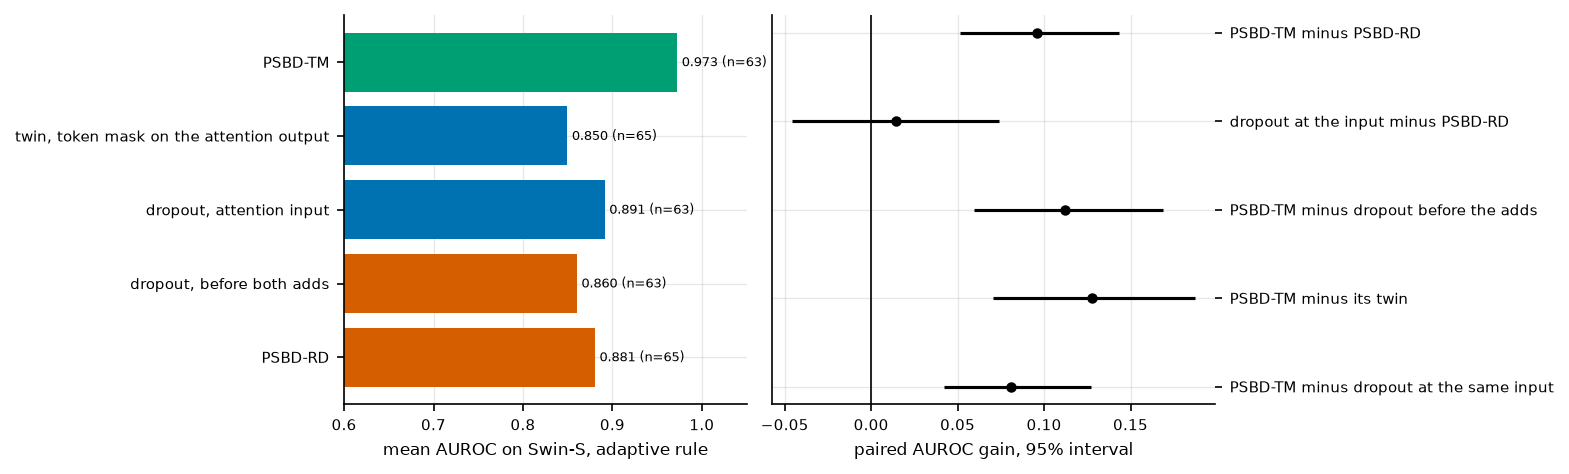

,n,gain,low,high
comparison,,,,
PSBD-TM minus PSBD-RD,63,0.096,0.051,0.144
dropout at the input minus PSBD-RD,63,0.015,-0.046,0.074
PSBD-TM minus dropout before the adds,63,0.112,0.059,0.169
PSBD-TM minus its twin,63,0.128,0.070,0.187
PSBD-TM minus dropout at the same input,63,0.081,0.042,0.127


In [5]:
SWIN_PLACEMENTS = {
    "PSBD-TM": RECOMMENDED_PLACEMENT,
    "twin, token mask on the attention output": tab_swin.TWIN_PLACEMENT,
    "dropout, attention input": tab_swin.SWIN_DROPOUT_INPUT,
    "dropout, before both adds": "pre_residual",
    "PSBD-RD": PUBLISHED_PLACEMENT,
}
means = {label: tab_swin.collect(swin, placement, "adaptive", HEADLINE_KEY, "auroc") for label, placement in SWIN_PLACEMENTS.items()}
GAINS = (
    ("SwinGainRecommendedMinusPublished", RECOMMENDED_PLACEMENT, PUBLISHED_PLACEMENT, "PSBD-TM minus PSBD-RD"),
    ("SwinGainDropoutInputMinusPublished", tab_swin.SWIN_DROPOUT_INPUT, PUBLISHED_PLACEMENT, "dropout at the input minus PSBD-RD"),
    ("SwinGainRecommendedMinusPreResidual", RECOMMENDED_PLACEMENT, "pre_residual", "PSBD-TM minus dropout before the adds"),
    ("SwinGainRecommendedMinusTwin", RECOMMENDED_PLACEMENT, tab_swin.TWIN_PLACEMENT, "PSBD-TM minus its twin"),
    ("SwinGainRecommendedMinusSameSiteDropout", RECOMMENDED_PLACEMENT, tab_swin.SWIN_DROPOUT_INPUT, "PSBD-TM minus dropout at the same input"),
)
gain_rows = []
for macro_stem, placement_a, placement_b, label in GAINS:
    deltas = tab_swin.paired_gain(swin, placement_a, placement_b, "adaptive")
    low, high = bootstrap_ci(deltas, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    gain_rows.append({"comparison": label, "n": len(deltas), "gain": mean_or_none(deltas), "low": low, "high": high})
    assert fmt(mean_or_none(deltas), signed=True) == macro("swin", macro_stem), macro_stem
    assert fmt(low, signed=True) == macro("swin", f"{macro_stem}Low"), macro_stem
gains = pd.DataFrame(gain_rows).set_index("comparison")
assert f"{np.mean(means['PSBD-TM']):.3f}" == macro("swin", "SwinRecommendedAurocAdaptive")
assert str(len(means["PSBD-TM"])) == macro("swin", "SwinRecommendedN")

figure, (mean_axis, gain_axis) = plt.subplots(1, 2, figsize=(10.5, 3.2), gridspec_kw={"width_ratios": [1, 1.1]})
labels = list(means)
mean_axis.barh(range(len(labels)), [np.mean(means[l]) for l in labels], color=["#009E73", "#0072B2", "#0072B2", "#D55E00", "#D55E00"])
for position, label in enumerate(labels):
    mean_axis.text(np.mean(means[label]) + 0.005, position, f"{np.mean(means[label]):.3f} (n={len(means[label])})", va="center", fontsize=6)
mean_axis.set_yticks(range(len(labels)), labels=labels, fontsize=7)
mean_axis.invert_yaxis()
mean_axis.set_xlim(0.6, 1.05)
mean_axis.set_xlabel("mean AUROC on Swin-S, adaptive rule")
errors = np.vstack([gains["gain"] - gains["low"], gains["high"] - gains["gain"]])  # (2, comparisons)
gain_axis.errorbar(gains["gain"], range(len(gains)), xerr=errors, fmt="o", color="black", ms=4)
gain_axis.set_yticks(range(len(gains)), labels=gains.index, fontsize=7)
gain_axis.yaxis.tick_right()
gain_axis.invert_yaxis()
gain_axis.axvline(0, color="black", lw=0.8)
gain_axis.set_xlabel("paired AUROC gain, 95% interval")
figure.tight_layout()
plt.show()
unreached = len(swin) - len(means["PSBD-TM"])
gains.round(3)

In [6]:
display(Markdown(rf"""
On Swin PSBD-TM averages {np.mean(means["PSBD-TM"]):.3f} over {len(means["PSBD-TM"])} models (`\SwinRecommendedAurocAdaptive`, {unreached} models never reach the adaptive shift target), and it beats PSBD-RD by {gains.loc["PSBD-TM minus PSBD-RD", "gain"]:+.3f} [{gains.loc["PSBD-TM minus PSBD-RD", "low"]:+.3f}, {gains.loc["PSBD-TM minus PSBD-RD", "high"]:+.3f}], against {macro("headline", "HeadlineGainAdaptiveAuroc")} on ViT. Moving dropout to the attention input gains {gains.loc["dropout at the input minus PSBD-RD", "gain"]:+.3f} with an interval of [{gains.loc["dropout at the input minus PSBD-RD", "low"]:+.3f}, {gains.loc["dropout at the input minus PSBD-RD", "high"]:+.3f}], so on Swin too the operator carries the gain at the input position. The difference from ViT is the twin. On ViT the twin ties PSBD-TM ({macro("staircase", "StaircaseOperatorsBeforeAttentionResidualTokenMaskGain").replace("$-$", "−")}), while on Swin PSBD-TM leads it by {gains.loc["PSBD-TM minus its twin", "gain"]:+.3f} [{gains.loc["PSBD-TM minus its twin", "low"]:+.3f}, {gains.loc["PSBD-TM minus its twin", "high"]:+.3f}], so on Swin masking the input of the windowed attention and masking its output are not the same probe. `docs/open-questions.md` (Q20) records this as open. The figure does not show per-attack detail, which `swin-per-attack.ipynb` gives. It also does not match models between architectures, the next figure.
"""))


On Swin PSBD-TM averages 0.973 over 63 models (`\SwinRecommendedAurocAdaptive`, 2 models never reach the adaptive shift target), and it beats PSBD-RD by +0.096 [+0.051, +0.144], against +0.075 on ViT. Moving dropout to the attention input gains +0.015 with an interval of [-0.046, +0.074], so on Swin too the operator carries the gain at the input position. The difference from ViT is the twin. On ViT the twin ties PSBD-TM (+0.002), while on Swin PSBD-TM leads it by +0.128 [+0.070, +0.187], so on Swin masking the input of the windowed attention and masking its output are not the same probe. `docs/open-questions.md` (Q20) records this as open. The figure does not show per-attack detail, which `swin-per-attack.ipynb` gives. It also does not match models between architectures, the next figure.


## Swin against ViT on the same attack cells

A Swin folder and a ViT folder with the same dataset, attack and rate are the same attack trained into 2 architectures. The scatter pairs them, 1 point per cell present and successful in both, so each point compares the architectures on identical poisoning.

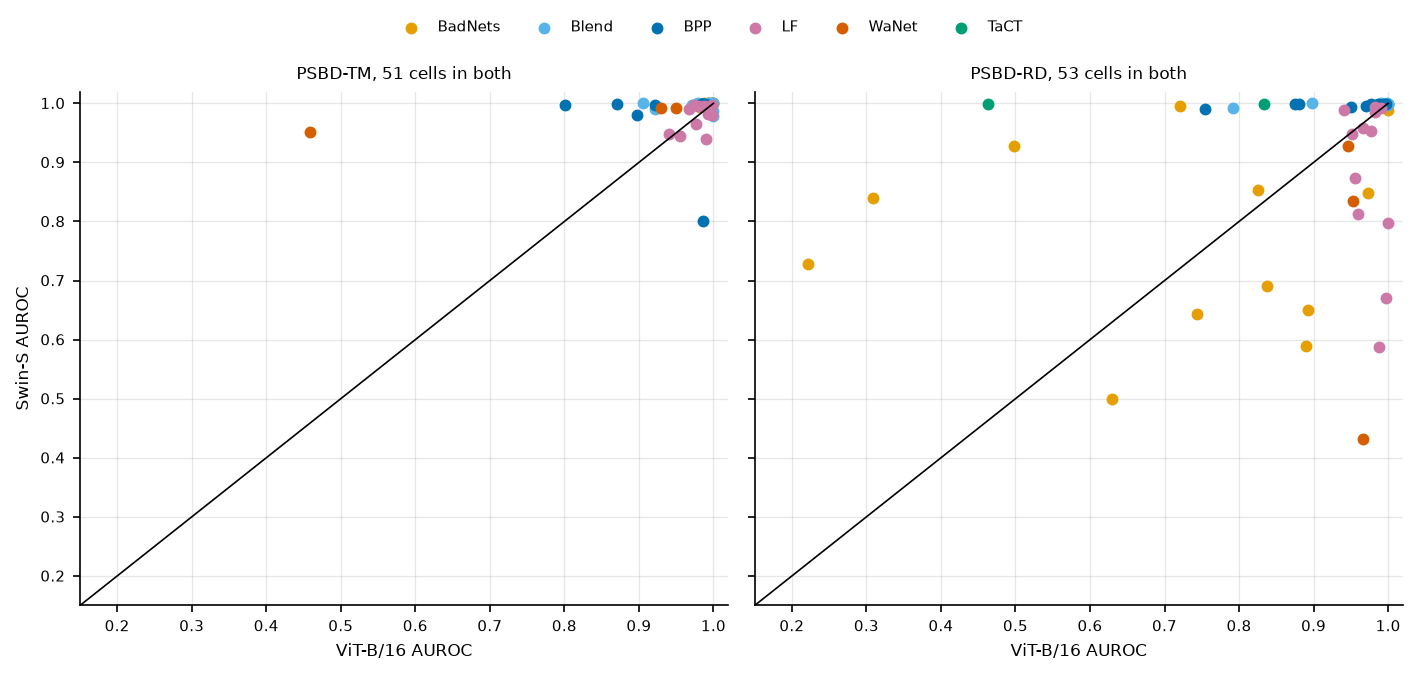

TM: 51 paired cells, ViT 0.963, Swin 0.988
RD: 53 paired cells, ViT 0.894, Swin 0.905


In [7]:
from cli.compare_detectors import psbd_values
from scripts.paper._common import clearing_cells, load_psbd_metrics

vit_reports = {cell["folder_name"]: load_psbd_metrics("results", cell["folder_name"]) for cell in clearing_cells(load_coverage("results"))}
pairs = []
for cell in swin:
    vit_folder = "vit_" + cell["folder"].removeprefix("swin_")
    if vit_folder not in vit_reports:
        continue
    row = {"cell": vit_folder.removeprefix("vit_"), "attack": cell["attack"]}
    for name, placement in (("TM", RECOMMENDED_PLACEMENT), ("RD", PUBLISHED_PLACEMENT)):
        for architecture, report in (("swin", cell["report"]), ("vit", vit_reports[vit_folder])):
            block = psbd_values(report, placement, "adaptive")
            row[f"{architecture}_{name}"] = None if block is None else block[HEADLINE_KEY]["auroc"]
    pairs.append(row)
paired = pd.DataFrame(pairs)

figure, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), sharex=True, sharey=True)
for axis, name, title in zip(axes, ("TM", "RD"), ("PSBD-TM", "PSBD-RD")):
    rows = paired.dropna(subset=[f"vit_{name}", f"swin_{name}"])
    for attack, attack_rows in rows.groupby("attack"):
        axis.scatter(attack_rows[f"vit_{name}"], attack_rows[f"swin_{name}"], s=22, color=attack_color(attack), label=attack_label(attack))
    axis.plot([0, 1], [0, 1], color="black", lw=0.8)
    axis.set_title(f"{title}, {len(rows)} cells in both", fontsize=8)
    axis.set_xlabel("ViT-B/16 AUROC")
axes[0].set_ylabel("Swin-S AUROC")
axes[0].set_xlim(0.15, 1.02)
axes[0].set_ylim(0.15, 1.02)
figure.tight_layout()
legend_above(figure, list(axes), columns=7)
plt.show()
for name in ("TM", "RD"):
    rows = paired.dropna(subset=[f"vit_{name}", f"swin_{name}"])
    print(f"{name}: {len(rows)} paired cells, ViT {rows[f'vit_{name}'].mean():.3f}, Swin {rows[f'swin_{name}'].mean():.3f}")
tm_pairs = paired.dropna(subset=["vit_TM", "swin_TM"])
rd_pairs = paired.dropna(subset=["vit_RD", "swin_RD"])
vit_outliers = tm_pairs[tm_pairs["vit_TM"] < 0.5]
rd_fall = rd_pairs[(rd_pairs["vit_RD"] > 0.9) & (rd_pairs["swin_RD"] < 0.85)]
rd_rise = rd_pairs[(rd_pairs["vit_RD"] < 0.85) & (rd_pairs["swin_RD"] > rd_pairs["vit_RD"])]

In [8]:
display(Markdown(rf"""
On the {len(tm_pairs)} cells both architectures implanted and PSBD-TM reached on both, PSBD-TM averages {tm_pairs["vit_TM"].mean():.3f} on ViT and {tm_pairs["swin_TM"].mean():.3f} on Swin, and the ViT models below chance ({word_list([f"`{c}`" for c in vit_outliers["cell"]])}) read {word_list([f"{v:.3f}" for v in vit_outliers["swin_TM"]])} on Swin. PSBD-RD averages {rd_pairs["vit_RD"].mean():.3f} on ViT and {rd_pairs["swin_RD"].mean():.3f} on Swin over its {len(rd_pairs)} cells, but the models it fails on change: {len(rd_rise)} cells it reads below 0.85 on ViT move up on Swin, while {len(rd_fall)} cells it reads above 0.9 on ViT ({word_list(sorted({attack_label(a) for a in rd_fall["attack"]}))}) fall below 0.85 on Swin. So PSBD-TM is stable across the 2 architectures and PSBD-RD is not. The figure covers only the cells that cleared on both, and a cell's Swin and ViT models share the poisoned training set but not the learned weights, so the pairing is by attack rather than by model.
"""))


On the 51 cells both architectures implanted and PSBD-TM reached on both, PSBD-TM averages 0.963 on ViT and 0.988 on Swin, and the ViT models below chance (`cifar10_wanet_0_1`) read 0.952 on Swin. PSBD-RD averages 0.894 on ViT and 0.905 on Swin over its 53 cells, but the models it fails on change: 9 cells it reads below 0.85 on ViT move up on Swin, while 7 cells it reads above 0.9 on ViT (BadNets, LF and WaNet) fall below 0.85 on Swin. So PSBD-TM is stable across the 2 architectures and PSBD-RD is not. The figure covers only the cells that cleared on both, and a cell's Swin and ViT models share the poisoned training set but not the learned weights, so the pairing is by attack rather than by model.


## An attacker who trains against the probe

Every result so far assumes an attacker who does not know PSBD exists. `results/adaptive_attacker_analysis.json` carries ViT-B/16 models trained with a hinge loss added to the backdoor objective, which pushes a poisoned sample's PSU under a chosen probe toward a clean sample's PSU, jointly with the backdoor itself (`attacks/evasion.py`). The probe trained against is token masking at the attention input (`token_mask@ban`, PSBD-TM's placement). `tab_adaptive.py` keeps the evasive models that kept their ASR at `HIGH_ASR` (`\AdaptiveVitCells`), and reads for each the probed operator's AUROC on the base and on the evasive model, the mean AUROC of the operators the attacker never trained against (dropout at the attention input and gain scaling at the MLP norm output), and the union of every probe.

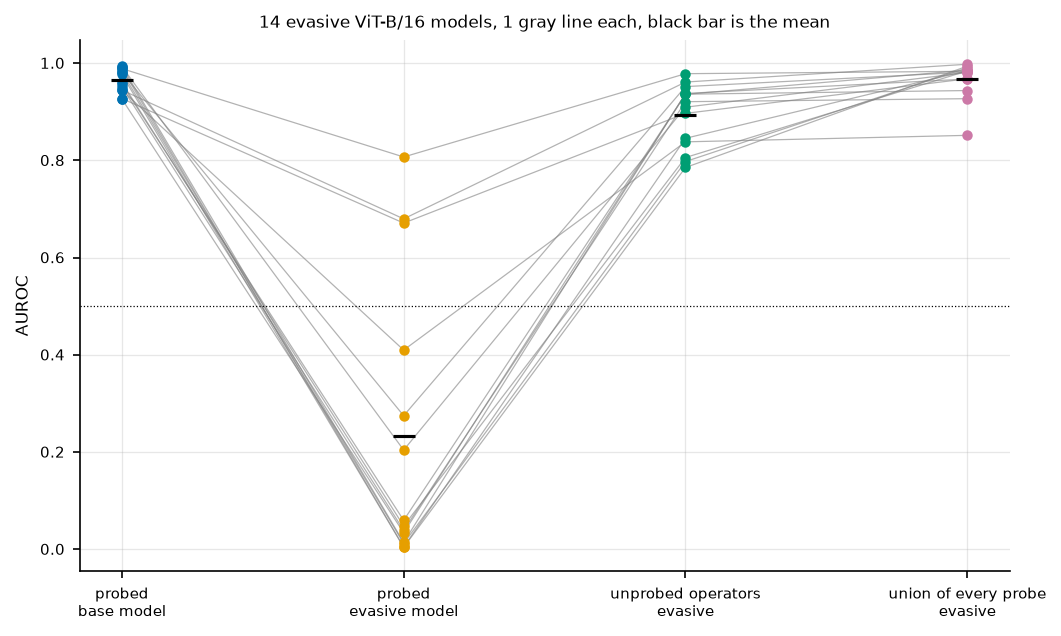

,"probed, base model","probed, evasive model","unprobed operators, evasive","union of every probe, evasive",clean accuracy cost
model,,,,,
cifar100 BadNets 0.1,0.989,0.005,0.846,0.985,-0.018
cifar100 Blend 0.1,0.982,0.012,0.798,0.991,-0.029
cifar100 Adaptive-Blend 0.1,0.951,0.039,0.921,0.927,-0.045
cifar100 LF 0.1,0.994,0.014,0.938,0.967,-0.026
cifar100 BPP 0.1,0.993,0.204,0.909,0.981,-0.045
cifar100 BadNets 0.05,0.977,0.004,0.785,0.994,-0.026
cifar100 Blend 0.05,0.989,0.807,0.978,0.983,-0.032
cifar100 Adaptive-Blend 0.05,0.927,0.034,0.936,0.944,-0.026
cifar100 LF 0.05,0.957,0.060,0.936,0.986,-0.032


In [9]:
from scripts.paper import tab_adaptive

attacker_rows = load_json("results/adaptive_attacker_analysis.json")
union_rows = {(r["arch"], r["dataset"], r["attack"], r["rate"]): r for r in load_json("results/multi_probe_analysis.json")}
evasive = []
for row in attacker_rows:
    if row["evade_asr"] < tab_adaptive.HIGH_ASR:
        continue
    probed = row["probed_label"].replace("@", "_at_")
    union = tab_adaptive.best_union(union_rows.get((row["arch"], row["dataset"], row["attack"], row["rate"]), {}))
    evasive.append({
        "model": f"{row['dataset']} {attack_label(row['attack'])} {row['rate']:g}",
        "probed, base model": row[f"{probed}_base"],
        "probed, evasive model": row[f"{probed}_evade"],
        "unprobed operators, evasive": mean_or_none(tab_adaptive.transfer_values(row)),
        "union of every probe, evasive": union,
        "clean accuracy cost": row["evade_ca"] - row["base_ca"],
    })
evasive = pd.DataFrame(evasive).set_index("model")
assert str(len(evasive)) == macro("adaptive", "AdaptiveVitCells")
assert fmt(evasive["probed, base model"].mean()) == macro("adaptive", "AdaptiveVitProbedBase")
assert fmt(evasive["probed, evasive model"].mean()) == macro("adaptive", "AdaptiveVitProbedEvade")
assert fmt(evasive["unprobed operators, evasive"].mean()) == macro("adaptive", "AdaptiveVitTransfer")
assert fmt(evasive["union of every probe, evasive"].mean()) == macro("adaptive", "AdaptiveVitUnion")

figure, axis = plt.subplots(figsize=(8.0, 4.6))
columns = ["probed, base model", "probed, evasive model", "unprobed operators, evasive", "union of every probe, evasive"]
for index, (model, row) in enumerate(evasive.iterrows()):
    axis.plot(range(len(columns)), row[columns], color="gray", lw=0.6, alpha=0.6)
for position, column in enumerate(columns):
    axis.scatter([position] * len(evasive), evasive[column], s=16, zorder=3)
    axis.scatter([position], [evasive[column].mean()], s=120, marker="_", color="black", zorder=4)
axis.axhline(0.5, color="black", lw=0.6, ls=":")
axis.set_xticks(range(len(columns)), labels=[c.replace(", ", "\n") for c in columns])
axis.set_ylabel("AUROC")
axis.set_title(f"{len(evasive)} evasive ViT-B/16 models, 1 gray line each, black bar is the mean", fontsize=8)
plt.show()
evasive_datasets = sorted({r["dataset"] for r in attacker_rows if r["evade_asr"] >= tab_adaptive.HIGH_ASR})
evasive.round(3)

In [10]:
display(Markdown(rf"""
The record holds {len(attacker_rows)} evasive models, of which {len(evasive)} keep ASR at least {tab_adaptive.HIGH_ASR}, all on {word_list([dataset_label(d) for d in evasive_datasets])}. Against the exact probe it trains against, the attacker wins outright. The probed AUROC falls from {evasive["probed, base model"].mean():.3f} on the base models to {evasive["probed, evasive model"].mean():.3f} on the evasive ones (`\AdaptiveVitProbedBase`, `\AdaptiveVitProbedEvade`), below chance, since the triggered images now shift more than clean ones. The operators it never trained against keep most of their separation ({evasive["unprobed operators, evasive"].mean():.3f}, `\AdaptiveVitTransfer`) and the union of every probe reads {evasive["union of every probe, evasive"].mean():.3f} (`\AdaptiveVitUnion`). The evasion changes clean accuracy by {100 * evasive["clean accuracy cost"].mean():+.1f} points on average and by {100 * evasive["clean accuracy cost"].min():+.1f} at worst. This is a defense against an attacker who targets 1 known probe. An attacker who trains against the union itself was not run, an open question the paper states. The figure does not show the union's false-positive rate, {macro("adaptive", "AdaptiveVitUnionFpr")} at the headline budget (`\AdaptiveVitUnionFpr`), the price of flagging on any of several probes.
"""))


The record holds 30 evasive models, of which 14 keep ASR at least 0.9, all on CIFAR-100. Against the exact probe it trains against, the attacker wins outright. The probed AUROC falls from 0.966 on the base models to 0.233 on the evasive ones (`\AdaptiveVitProbedBase`, `\AdaptiveVitProbedEvade`), below chance, since the triggered images now shift more than clean ones. The operators it never trained against keep most of their separation (0.893, `\AdaptiveVitTransfer`) and the union of every probe reads 0.967 (`\AdaptiveVitUnion`). The evasion changes clean accuracy by -3.0 points on average and by -4.5 at worst. This is a defense against an attacker who targets 1 known probe. An attacker who trains against the union itself was not run, an open question the paper states. The figure does not show the union's false-positive rate, 0.26 at the headline budget (`\AdaptiveVitUnionFpr`), the price of flagging on any of several probes.


## The union of probes on ordinary models

If a union is the answer to an adaptive attacker, it should not cost detection on ordinary backdoors. `experiments/probe_union/` scores the headline models with unions of placements, a union scoring each input by its lowest rank across the probes, and `scripts/paper/tab_probe_union.py` reads it.

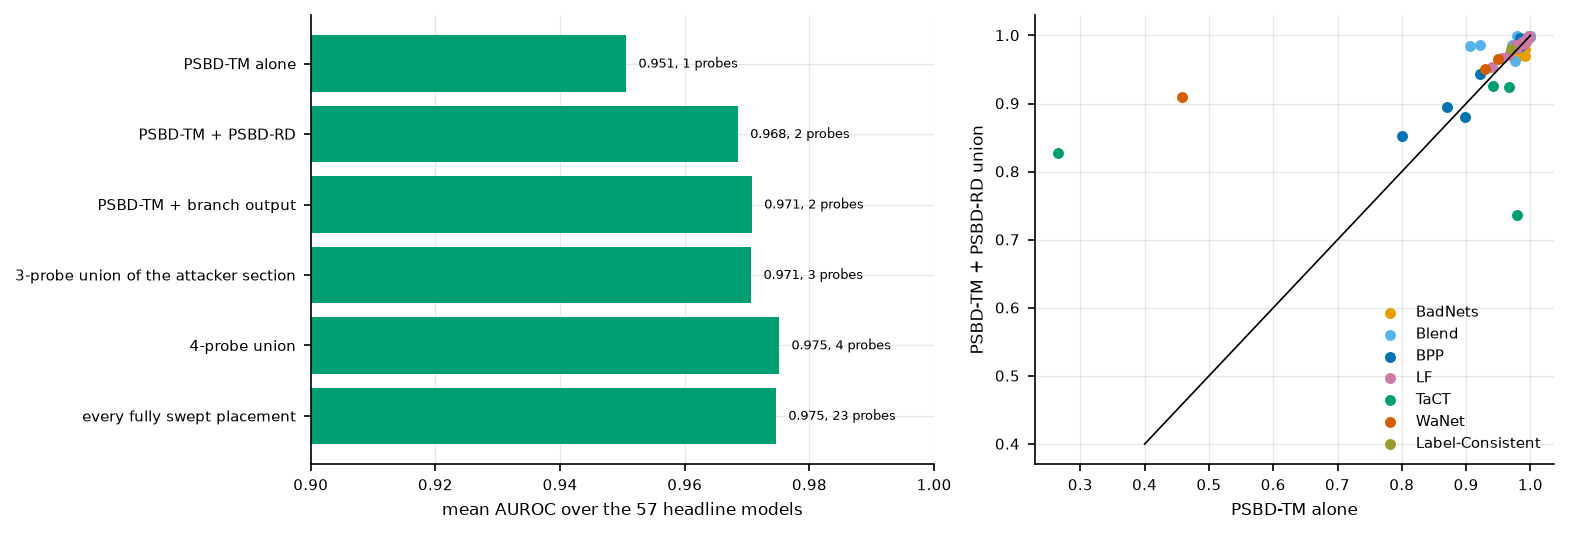

WaNet 10% CIFAR-10: PSBD-TM 0.459, PSBD-TM + PSBD-RD 0.910


,placements,models,AUROC,TPR at q0.10
union,,,,
PSBD-TM alone,1,56,0.951,0.872
PSBD-TM + PSBD-RD,2,56,0.968,0.895
PSBD-TM + branch output,2,56,0.971,0.894
3-probe union of the attacker section,3,56,0.971,0.898
4-probe union,4,56,0.975,0.913
every fully swept placement,23,56,0.975,0.911


In [11]:
union_record = load_json("results/_experiments/probe_union/probe_union.json")
# The record was written over the ASR-only panel, so its summaries are recomputed
# on the successful models by the paper generator's own restrict_to_panel.
from scripts.paper.tab_probe_union import restrict_to_panel
from scripts.paper._common import BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED
union_panel = {cell["folder_name"] for cell in clearing_cells_of(load_coverage("results"))}
restricted = restrict_to_panel(union_record, union_panel, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
for key, block in restricted.items():
    block["summary"]["placements"] = union_record["probe_sets"][key]["summary"]["placements"]
union_record = {**union_record, "probe_sets": restricted}
set_labels = {
    "psbd_tm": "PSBD-TM alone",
    "psbd_tm_rd": "PSBD-TM + PSBD-RD",
    "psbd_tm_attn_branch": "PSBD-TM + branch output",
    "adaptive_3probe": "3-probe union of the attacker section",
    "adaptive_4probe": "4-probe union",
    "all_65_basis": "every fully swept placement",
}
union_summary = pd.DataFrame(
    [
        {"union": label, "placements": len(union_record["probe_sets"][key]["summary"]["placements"]),
         "models": union_record["probe_sets"][key]["summary"]["n_models"],
         "AUROC": union_record["probe_sets"][key]["summary"]["auroc_mean"],
         "TPR at q0.10": union_record["probe_sets"][key]["summary"]["tpr_at_0.10_mean"]}
        for key, label in set_labels.items() if key in union_record["probe_sets"]
    ]
).set_index("union")
assert fmt(union_summary.loc["PSBD-TM alone", "AUROC"]) == macro("probe_union", "ProbeUnionPsbdTmAuroc")
assert fmt(union_summary.loc["PSBD-TM + branch output", "AUROC"]) == macro("probe_union", "ProbeUnionTmBranchAuroc")

per_model = {key: pd.DataFrame(union_record["probe_sets"][key]["per_model"]).set_index("folder")["auroc"] for key in ("psbd_tm", "psbd_tm_rd")}
attacks_of = pd.DataFrame(union_record["probe_sets"]["psbd_tm"]["per_model"]).set_index("folder")["attack"]

figure, (bar_axis, scatter_axis) = plt.subplots(1, 2, figsize=(10.5, 3.6), gridspec_kw={"width_ratios": [1.2, 1]})
bar_axis.barh(range(len(union_summary)), union_summary["AUROC"], color="#009E73")
for position, (auroc, n) in enumerate(zip(union_summary["AUROC"], union_summary["placements"])):
    bar_axis.text(auroc + 0.002, position, f"{auroc:.3f}, {n} probes", va="center", fontsize=6)
bar_axis.set_yticks(range(len(union_summary)), labels=union_summary.index, fontsize=7)
bar_axis.invert_yaxis()
bar_axis.set_xlim(0.9, 1.0)
bar_axis.set_xlabel("mean AUROC over the 57 headline models")
for attack in attacks_of.unique():
    folders = attacks_of[attacks_of == attack].index
    scatter_axis.scatter(per_model["psbd_tm"][folders], per_model["psbd_tm_rd"][folders], s=18, color=attack_color(attack), label=attack_label(attack))
scatter_axis.plot([0.4, 1], [0.4, 1], color="black", lw=0.8)
scatter_axis.set_xlabel("PSBD-TM alone")
scatter_axis.set_ylabel("PSBD-TM + PSBD-RD union")
scatter_axis.legend()
figure.tight_layout()
plt.show()
wanet = union_record["wanet_cifar10"]
print(f"WaNet 10% CIFAR-10: PSBD-TM {wanet['psbd_tm']['auroc']:.3f}, PSBD-TM + PSBD-RD {wanet['psbd_tm_rd']['auroc']:.3f}")
alone = union_summary.loc["PSBD-TM alone", "AUROC"]
assert (union_summary["AUROC"] >= alone - 1e-9).all(), "the reading says no union falls below PSBD-TM alone"
union_summary.round(3)

In [12]:
display(Markdown(rf"""
Every union reads at least as high as PSBD-TM alone ({alone:.3f}) on the {union_summary.loc["PSBD-TM alone", "models"]} ordinary models, so hardening against an adaptive attacker costs nothing in AUROC. PSBD-TM plus PSBD-RD gains {macro("probe_union", "ProbeUnionTmRdGain")} with an interval of {macro("probe_union", "ProbeUnionTmRdGainCi").replace("$-$", "−")} (`\ProbeUnionTmRdGain`). The scatter shows where: it lifts WaNet at 10% on CIFAR-10 from {wanet["psbd_tm"]["auroc"]:.3f} to {wanet["psbd_tm_rd"]["auroc"]:.3f}, the cell where PSBD-TM inverts and PSBD-RD is strong, and leaves the rest near the diagonal. The figure does not show the union's FPR, which rises with the number of probes at a fixed per-probe quantile.
"""))


Every union reads at least as high as PSBD-TM alone (0.951) on the 56 ordinary models, so hardening against an adaptive attacker costs nothing in AUROC. PSBD-TM plus PSBD-RD gains +0.018 with an interval of [−0.005, +0.047] (`\ProbeUnionTmRdGain`). The scatter shows where: it lifts WaNet at 10% on CIFAR-10 from 0.459 to 0.910, the cell where PSBD-TM inverts and PSBD-RD is strong, and leaves the rest near the diagonal. The figure does not show the union's FPR, which rises with the number of probes at a fixed per-probe quantile.


## Forward passes and their cost

PSBD's price is 1 extra forward pass per perturbed pass. `experiments/psbd_cost/measure.py` timed a plain prediction against PSBD at several $k$, on the GPU and batch size named in the record, for both architectures. `results/_experiments/psbd_cost/cost.json` carries it. What a larger $k$ buys in detection comes from the sweeps themselves: `scripts/paper/fig_forward_passes.py` reads PSBD-TM at $k$ up to the cached default on every headline model (the first $k$ passes of the cached ones) and up to the largest $k$ on the models swept with more passes.

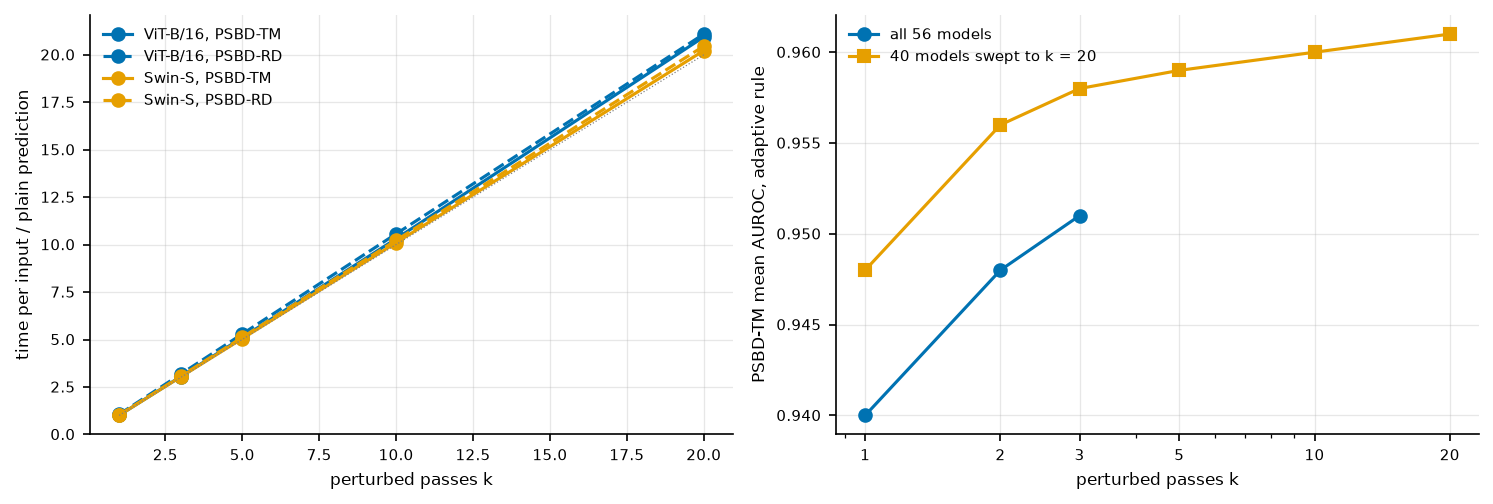

GPU NVIDIA A100-PCIE-40GB, batch 128, 512 images, rate 0.3
ViT-B/16 at k = 3: 3.04 times a plain prediction, 2.20 ms plain per input


In [13]:
cost = load_json("results/_experiments/psbd_cost/cost.json")
figure, (cost_axis, gain_axis) = plt.subplots(1, 2, figsize=(10.0, 3.4))
for architecture, color in (("vit", "#0072B2"), ("swin", "#E69F00")):
    record = cost["architectures"][architecture]
    plain = record["plain"]["seconds_per_input"]
    for placement, style in (("token_mask_before_attention_norm", "-"), ("dropout_post_residual", "--")):
        if placement not in record["placements"]:
            continue
        by_k = record["placements"][placement]["by_k"]
        ks = sorted(by_k, key=int)
        cost_axis.plot([int(k) for k in ks], [by_k[k]["seconds_per_input"] / plain for k in ks], marker="o", ls=style, color=color,
                       label=f"{'ViT-B/16' if architecture == 'vit' else 'Swin-S'}, {'PSBD-TM' if placement.startswith('token') else 'PSBD-RD'}")
cost_axis.plot([1, 20], [1, 20], color="gray", lw=0.6, ls=":")
cost_axis.set_xlabel("perturbed passes k")
cost_axis.set_ylabel("time per input / plain prediction")
cost_axis.legend()

k_all = {1: "KOne", 2: "KTwo", 3: "KThree"}
k_pilot = {1: "KOne", 2: "KTwo", 3: "KThree", 5: "KFive", 10: "KOneZero", 20: "KTwoZero"}
gain_axis.plot(list(k_all), [float(macro("forward_passes", f"PassAllAuroc{s}")) for s in k_all.values()], marker="o", label=f"all {macro('forward_passes', 'PassAllCells')} models")
gain_axis.plot(list(k_pilot), [float(macro("forward_passes", f"PassPilotAuroc{s}")) for s in k_pilot.values()], marker="s", label=f"{macro('forward_passes', 'PassPilotCells')} models swept to k = 20")
gain_axis.set_xscale("log")
gain_axis.set_xticks([1, 2, 3, 5, 10, 20], labels=["1", "2", "3", "5", "10", "20"])
gain_axis.set_xlabel("perturbed passes k")
gain_axis.set_ylabel("PSBD-TM mean AUROC, adaptive rule")
gain_axis.legend()
figure.tight_layout()
plt.show()

vit = cost["architectures"]["vit"]
slowdown_3 = vit["placements"]["token_mask_before_attention_norm"]["by_k"]["3"]["seconds_per_input"] / vit["plain"]["seconds_per_input"]
assert f"{slowdown_3:.2f}x" == macro("cost", "CostSlowdownKThreeVit")
print(f"GPU {cost['gpu_name']}, batch {cost['batch_size']}, {cost['num_images']} images, rate {cost['perturbation_rate']}")
print(f"ViT-B/16 at k = 3: {slowdown_3:.2f} times a plain prediction, {vit['plain']['seconds_per_input'] * 1000:.2f} ms plain per input")
swin_cost = cost["architectures"]["swin"]
swin_slowdown_3 = swin_cost["placements"]["token_mask_before_attention_norm"]["by_k"]["3"]["seconds_per_input"] / swin_cost["plain"]["seconds_per_input"]
tm_20 = vit["placements"]["token_mask_before_attention_norm"]["by_k"]["20"]["seconds_per_input"]
tm_3 = vit["placements"]["token_mask_before_attention_norm"]["by_k"]["3"]["seconds_per_input"]

In [14]:
display(Markdown(rf"""
Time grows linearly in $k$ on both architectures, PSBD-TM at $k=3$ costing {slowdown_3:.2f} times a plain prediction on ViT-B/16 and {swin_slowdown_3:.2f} on Swin-S (`\CostSlowdownKThreeVit`, `\CostSlowdownKThreeSwin`). The 2 placements cost about the same, since a hook adds almost nothing to a pass. Detection saturates early. From $k=1$ to $k=3$ mean AUROC rises by {macro("forward_passes", "PassAllAurocGainFull")} over the {macro("forward_passes", "PassAllCells")} headline models, and on the {macro("forward_passes", "PassPilotCells")} models swept to $k=20$ the step from 3 to 20 adds {macro("forward_passes", "PassPilotAurocGainBeyondThree")} (`\PassPilotAurocGainBeyondThree`) for {tm_20 / tm_3:.1f} times the cost. $k=3$ is the PSBD paper's own choice, carried here. It sits at the knee. The pilot models are an easier subset than the panel (their $k=1$ mean is already {macro("forward_passes", "PassPilotAurocKOne")}), so the saturation is measured where it is easiest to see.
"""))


Time grows linearly in $k$ on both architectures, PSBD-TM at $k=3$ costing 3.04 times a plain prediction on ViT-B/16 and 3.03 on Swin-S (`\CostSlowdownKThreeVit`, `\CostSlowdownKThreeSwin`). The 2 placements cost about the same, since a hook adds almost nothing to a pass. Detection saturates early. From $k=1$ to $k=3$ mean AUROC rises by +0.010 over the 56 headline models, and on the 40 models swept to $k=20$ the step from 3 to 20 adds +0.003 (`\PassPilotAurocGainBeyondThree`) for 6.9 times the cost. $k=3$ is the PSBD paper's own choice, carried here. It sits at the knee. The pilot models are an easier subset than the panel (their $k=1$ mean is already 0.948), so the saturation is measured where it is easiest to see.


## What this notebook establishes

The ranking transfers to Swin-S, with a larger gain over PSBD-RD than on ViT and with the twin placement separating from PSBD-TM, the 1 place where the 2 architectures disagree. An attacker who trains against PSBD-TM defeats it, and a union of probes it did not train against restores detection without costing anything on ordinary models. PSBD-TM costs 3 forward passes per input, and more passes buy little. `swin-per-attack.ipynb` breaks the Swin result out per attack, and `reproducing-the-paper.ipynb` shows how every number here reaches the paper.